In [60]:
import yfinance as yf
from pandas_datareader import data as pdr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [61]:
# style for better plots
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [62]:
print("=" * 60)
print("STEP 1: DATA COLLECTION & PREPROCESSING")
print("=" * 60)

# 1. Defining the date range

START_DATE = "2007-01-01"  # Captures 2008 crisis
END_DATE = "2024-12-31"    # Recent data

print(f"\n📅 Date Range: {START_DATE} to {END_DATE}")

STEP 1: DATA COLLECTION & PREPROCESSING

📅 Date Range: 2007-01-01 to 2024-12-31


In [63]:
# loading equity market data while keeping it robust and scalable

print("\n📈 Loading equity market data...")

tickers = {
    '^GSPC': 'sp500',              # S&P 500 Index
    '^VIX': 'vix',                 # Volatility Index
    'HYG': 'high_yield_bonds',     # Credit stress
    'XLF': 'financials_sector',    # Banking sector
    'GLD': 'gold',                 # Safe haven

    # ---- new tickers can be added here ----
    # 'TLT': 'long_treasury',
    # 'LQD': 'investment_grade_bonds',
    # 'USO': 'oil',
    # 'UUP': 'dollar_index',
}

# downloading aLL tickers together into one variable
raw_data = yf.download(
    list(tickers.keys()),
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)

# to extract close prices safely
close_prices = raw_data['Close']

# rename columns using mapping
close_prices.rename(columns=tickers, inplace=True)

df_equity = close_prices.copy()          # deep copy - original data will be unaffected in close_prices

print(f"✅ Equity data loaded: {df_equity.shape[0]} rows")
print(f"   Features: {list(df_equity.columns)}")


📈 Loading equity market data...
✅ Equity data loaded: 4529 rows
   Features: ['gold', 'high_yield_bonds', 'financials_sector', 'sp500', 'vix']


In [64]:
# ticker logging
print("\nLoaded indicators:")
for col in df_equity.columns:
    print(f"   • {col}")


Loaded indicators:
   • gold
   • high_yield_bonds
   • financials_sector
   • sp500
   • vix


In [65]:
# to understand the basic structure
df_equity.head(9)

Ticker,gold,high_yield_bonds,financials_sector,sp500,vix
Date,,,,,
2007-01-03,62.279999,NaN,20.661739,1416.599976,12.04
2007-01-04,61.650002,NaN,20.594574,1418.339966,11.51
2007-01-05,60.169998,NaN,20.432281,1409.709961,12.14
2007-01-08,60.480000,NaN,20.521812,1412.839966,12.00
2007-01-09,60.849998,NaN,20.488245,1412.109985,11.91
2007-01-10,60.590000,NaN,20.555399,1414.849976,11.47
2007-01-11,60.630001,NaN,20.684113,1423.819946,10.87
2007-01-12,62.169998,NaN,20.706499,1430.729980,10.15
2007-01-16,61.970001,NaN,20.762457,1431.900024,10.74


In [66]:
# understand the data type and shape
print(df_equity.info(), '\n')
print('Shape:', df_equity.shape)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4529 entries, 2007-01-03 to 2024-12-30
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gold               4529 non-null   float64
 1   high_yield_bonds   4462 non-null   float64
 2   financials_sector  4529 non-null   float64
 3   sp500              4529 non-null   float64
 4   vix                4529 non-null   float64
dtypes: float64(5)
memory usage: 212.3 KB
None 

Shape: (4529, 5)


In [67]:
# understand the statistics of our data
df_equity.describe()

Ticker,gold,high_yield_bonds,financials_sector,sp500,vix
count,4529.000000,4462.000000,4529.000000,4529.000000,4529.000000
mean,136.080614,50.898660,20.037876,2474.934725,19.858938
std,37.465390,12.733101,9.968326,1288.459258,8.962725
min,60.169998,22.205807,3.699350,676.530029,9.140000
25%,114.309998,40.456952,11.624565,1395.949951,13.850000
50%,126.599998,50.977356,17.504265,2087.790039,17.500000
75%,165.289993,62.001283,25.278378,3273.399902,22.940001
max,257.500000,74.672638,50.420219,6090.270020,82.690002


In [68]:
# 3. Loading bond/treasury data (FRED)

print("\n📊 Loading Treasury yield data from FRED...")

fred_tickers = {
    'DGS10': 'treasury_10y',    # 10-Year Treasury
    'DGS2': 'treasury_2y',      # 2-Year Treasury
    'DGS3MO': 'treasury_3m',    # 3-Month Treasury
}

bond_data = {}
for ticker, name in fred_tickers.items():
    print(f"   Downloading {name.upper()}...")
    try:
        df = pdr.DataReader(ticker, 'fred', start=START_DATE, end=END_DATE)
        bond_data[name] = df[ticker]
    except Exception as e:
        print(f"   ⚠️ Warning: Could not load {name}: {e}")

df_bonds = pd.DataFrame(bond_data)

print(f"✅ Bond data loaded: {df_bonds.shape[0]} rows")


📊 Loading Treasury yield data from FRED...
✅ Bond data loaded: 4697 rows


In [69]:
# understand the data type and shape
print(df_bonds.info(), '\n')
print('Shape:', df_bonds.shape)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4697 entries, 2007-01-01 to 2024-12-31
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   treasury_10y  4504 non-null   float64
 1   treasury_2y   4504 non-null   float64
 2   treasury_3m   4504 non-null   float64
dtypes: float64(3)
memory usage: 146.8 KB
None 

Shape: (4697, 3)


In [70]:
df_bonds.head(9)

,treasury_10y,treasury_2y,treasury_3m
DATE,,,
2007-01-01,NaN,NaN,NaN
2007-01-02,4.68,4.80,5.07
2007-01-03,4.67,4.76,5.05
2007-01-04,4.62,4.71,5.04
2007-01-05,4.65,4.76,5.05
2007-01-08,4.66,4.78,5.08
2007-01-09,4.66,4.79,5.08
2007-01-10,4.69,4.81,5.09
2007-01-11,4.74,4.86,5.11


In [71]:
# understand the statistics of our data
df_bonds.describe()

,treasury_10y,treasury_2y,treasury_3m
count,4504.000000,4504.000000,4504.000000
mean,2.725624,1.640537,1.374116
std,1.029401,1.530462,1.839088
min,0.520000,0.090000,0.000000
25%,1.940000,0.410000,0.070000
50%,2.610000,0.940000,0.230000
75%,3.540000,2.530000,2.112500
max,5.260000,5.190000,5.630000


In [72]:
# 4. loading Credit Spread Data (FRED)

print("\n💳 Loading credit spread data from FRED...")

try:
    # BAA Corporate Bond Yield minus 10-Year Treasury

    credit_spread = pdr.DataReader('BAA10Y', 'fred', start=START_DATE, end=END_DATE)
    df_credit = credit_spread.rename(columns={'BAA10Y': 'credit_spread'})
    print(f"✅ Credit spread loaded: {df_credit.shape[0]} rows")

except Exception as e:

    print(f"⚠️ Warning: Could not load credit spread: {e}")
    df_credit = pd.DataFrame()


💳 Loading credit spread data from FRED...
✅ Credit spread loaded: 4697 rows


In [73]:
print(df_bonds.info(), '\n')
print('Shape:', df_bonds.shape)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4697 entries, 2007-01-01 to 2024-12-31
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   treasury_10y  4504 non-null   float64
 1   treasury_2y   4504 non-null   float64
 2   treasury_3m   4504 non-null   float64
dtypes: float64(3)
memory usage: 146.8 KB
None 

Shape: (4697, 3)


In [74]:
df_credit.head(9)

,credit_spread
DATE,
2007-01-01,NaN
2007-01-02,1.64
2007-01-03,1.61
2007-01-04,1.62
2007-01-05,1.60
2007-01-08,1.59
2007-01-09,1.59
2007-01-10,1.59
2007-01-11,1.59


In [75]:
# understand the statistics of our data
df_credit.describe()

,credit_spread
count,4500.000000
mean,2.542924
std,0.787680
min,1.360000
25%,1.990000
50%,2.405000
75%,2.912500
max,6.160000


In [76]:

print("\n🔗 Merging all datasets...")

# Start with equity data
df = df_equity.copy()

# Merge bonds
df = df.join(df_bonds, how='outer')

# Merge credit spread
if not df_credit.empty:
    df = df.join(df_credit, how='outer')

print(f"✅ Combined dataset shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")


🔗 Merging all datasets...
✅ Combined dataset shape: (4697, 9)
   Columns: ['gold', 'high_yield_bonds', 'financials_sector', 'sp500', 'vix', 'treasury_10y', 'treasury_2y', 'treasury_3m', 'credit_spread']


In [77]:
# 5. making a function to merge all the datasets

def merge_datasets(datasets):
    """Merge multiple datasets with outer join."""
    df = pd.DataFrame()

    for name, data in datasets.items():
        if data.empty:
            print(f"⚠️  Skipping empty dataset: {name}")
            continue

        if df.empty:
            df = data.copy()
            print(f"✅ Started with: {name}")
        else:
            df = df.join(data, how='outer')
            print(f"✅ Merged: {name}")

    return df

# if wanted you can add more
datasets = {
    'equity': df_equity,
    'bonds': df_bonds,
    'credit': df_credit
}

df = merge_datasets(datasets)
print(f"\n✅ Combined dataset shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")

✅ Started with: equity
✅ Merged: bonds
✅ Merged: credit

✅ Combined dataset shape: (4697, 9)
   Columns: ['gold', 'high_yield_bonds', 'financials_sector', 'sp500', 'vix', 'treasury_10y', 'treasury_2y', 'treasury_3m', 'credit_spread']


In [78]:
# checking on how the merged data set looks
df.head()

,gold,high_yield_bonds,financials_sector,sp500,vix,treasury_10y,treasury_2y,treasury_3m,credit_spread
2007-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-02,NaN,NaN,NaN,NaN,NaN,4.68,4.80,5.07,1.64
2007-01-03,62.279999,NaN,20.661739,1416.599976,12.04,4.67,4.76,5.05,1.61
2007-01-04,61.650002,NaN,20.594574,1418.339966,11.51,4.62,4.71,5.04,1.62
2007-01-05,60.169998,NaN,20.432281,1409.709961,12.14,4.65,4.76,5.05,1.60


In [79]:
# understand the data type and shape
print(df.info(), '\n')
print('Shape:', df.shape)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4697 entries, 2007-01-01 to 2024-12-31
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gold               4529 non-null   float64
 1   high_yield_bonds   4462 non-null   float64
 2   financials_sector  4529 non-null   float64
 3   sp500              4529 non-null   float64
 4   vix                4529 non-null   float64
 5   treasury_10y       4504 non-null   float64
 6   treasury_2y        4504 non-null   float64
 7   treasury_3m        4504 non-null   float64
 8   credit_spread      4500 non-null   float64
dtypes: float64(9)
memory usage: 496.0 KB
None 

Shape: (4697, 9)


In [80]:
# 6. data cleaning

# Goal: Prepare time series data for financial analysis while preserving data integrity

# Key Considerations:
# 1. Financial markets are closed on weekends/holidays → NaNs are EXPECTED
# 2. Different data sources may have different coverage periods
# 3. Forward-filling is generally acceptable for prices (last known value carries forward)
# 4. We need to distinguish between "missing because market closed" vs "missing data quality issue"

In [81]:
# to gain some intution about our data
print(" STEP 1: Understand the missing data pattern\n")

# Calculate missing data statistics
missing_counts = df.isna().sum()
missing_pcts = (missing_counts / len(df) * 100).round(2)

print("Missing data by column:")
for col in df.columns:
    print(f"  {col:20s}: {missing_counts[col]:4d} missing ({missing_pcts[col]:5.2f}%)")

# Check when each series actually starts
print("\n First available data point for each column:")
for col in df.columns:
    first_date = df[col].first_valid_index()
    print(f"  {col:20s}: {first_date}")

 STEP 1: Understand the missing data pattern

Missing data by column:
  gold                :  168 missing ( 3.58%)
  high_yield_bonds    :  235 missing ( 5.00%)
  financials_sector   :  168 missing ( 3.58%)
  sp500               :  168 missing ( 3.58%)
  vix                 :  168 missing ( 3.58%)
  treasury_10y        :  193 missing ( 4.11%)
  treasury_2y         :  193 missing ( 4.11%)
  treasury_3m         :  193 missing ( 4.11%)
  credit_spread       :  197 missing ( 4.19%)

 First available data point for each column:
  gold                : 2007-01-03 00:00:00
  high_yield_bonds    : 2007-04-11 00:00:00
  financials_sector   : 2007-01-03 00:00:00
  sp500               : 2007-01-03 00:00:00
  vix                 : 2007-01-03 00:00:00
  treasury_10y        : 2007-01-02 00:00:00
  treasury_2y         : 2007-01-02 00:00:00
  treasury_3m         : 2007-01-02 00:00:00
  credit_spread       : 2007-01-02 00:00:00


In [82]:
# to gain some intution about our data

print(f"Total rows: {len(df)}", "\n")
print(f"Date range: {df.index.min()} to {df.index.max()}", "\n")
print(f"Trading days (approx): ~252 per year × 18 years = ~4,536 days", "\n")
print(f"Our data: {len(df)} rows")

Total rows: 4697 

Date range: 2007-01-01 00:00:00 to 2024-12-31 00:00:00 

Trading days (approx): ~252 per year × 18 years = ~4,536 days 

Our data: 4697 rows


In [83]:
# checking whether the days included have weekends

print(" Day of Week Analysis\n")

# Add day of week to understand the pattern
df['day_of_week'] = df.index.day_name()
df['is_weekend'] = df.index.dayofweek >= 5  # Saturday=5, Sunday=6

# Count occurrences of each day
day_counts = df['day_of_week'].value_counts().sort_index()
print("Rows per day of week:")
print(day_counts)

# Check weekend rows
weekend_rows = df[df['is_weekend']]
print(f"\n Weekend rows: {len(weekend_rows)}")
print(f"   Saturdays: {(df.index.dayofweek == 5).sum()}")
print(f"   Sundays: {(df.index.dayofweek == 6).sum()}")

# Check if weekend rows have data
weekend_data = df[df['is_weekend']].notna().any(axis=1).sum()
print(f"   Weekend rows with ANY data: {weekend_data}")
print(f"   Weekend rows completely empty: {len(weekend_rows) - weekend_data}")

# Expected counts
import datetime
start = df.index.min()
end = df.index.max()
total_days = (end - start).days + 1
expected_trading_days = len(pd.bdate_range(start, end))  # Business days

print(f"\n Comparison:")
print(f"   Total calendar days: {total_days}")
print(f"   Our dataset rows: {len(df)}")
print(f"   Expected trading days (excl weekends): {expected_trading_days}")
print(f"   Match? {total_days == len(df)}")

# Show some weekend rows
print(f"\n Sample weekend rows (should be mostly empty):")
print(weekend_rows.head(10))

# Clean up temporary columns
df.drop(['day_of_week', 'is_weekend'], axis=1, inplace=True)

 Day of Week Analysis

Rows per day of week:
day_of_week
Friday       939
Monday       940
Thursday     939
Tuesday      940
Wednesday    939
Name: count, dtype: int64

 Weekend rows: 0
   Saturdays: 0
   Sundays: 0
   Weekend rows with ANY data: 0
   Weekend rows completely empty: 0

 Comparison:
   Total calendar days: 6575
   Our dataset rows: 4697
   Expected trading days (excl weekends): 4697
   Match? False

 Sample weekend rows (should be mostly empty):
Empty DataFrame
Columns: [gold, high_yield_bonds, financials_sector, sp500, vix, treasury_10y, treasury_2y, treasury_3m, credit_spread, day_of_week, is_weekend]
Index: []


In [84]:
# Find those 159 mystery empty rows
completely_empty_rows = df[df.isna().all(axis=1)]

print(f"🔍 The {len(completely_empty_rows)} completely empty rows:")
print(completely_empty_rows.index.to_list()[:20])  # Show first 20

# Check if they're holidays
print("\n📅 Are these US market holidays?")
for date in completely_empty_rows.index[:10]:
    print(f"  {date.strftime('%Y-%m-%d %A')}")


🔍 The 159 completely empty rows:
[Timestamp('2007-01-01 00:00:00'), Timestamp('2007-01-15 00:00:00'), Timestamp('2007-02-19 00:00:00'), Timestamp('2007-05-28 00:00:00'), Timestamp('2007-07-04 00:00:00'), Timestamp('2007-09-03 00:00:00'), Timestamp('2007-11-22 00:00:00'), Timestamp('2007-12-25 00:00:00'), Timestamp('2008-01-01 00:00:00'), Timestamp('2008-01-21 00:00:00'), Timestamp('2008-02-18 00:00:00'), Timestamp('2008-03-21 00:00:00'), Timestamp('2008-05-26 00:00:00'), Timestamp('2008-07-04 00:00:00'), Timestamp('2008-09-01 00:00:00'), Timestamp('2008-11-27 00:00:00'), Timestamp('2008-12-25 00:00:00'), Timestamp('2009-01-01 00:00:00'), Timestamp('2009-01-19 00:00:00'), Timestamp('2009-02-16 00:00:00')]

📅 Are these US market holidays?
  2007-01-01 Monday
  2007-01-15 Monday
  2007-02-19 Monday
  2007-05-28 Monday
  2007-07-04 Wednesday
  2007-09-03 Monday
  2007-11-22 Thursday
  2007-12-25 Tuesday
  2008-01-01 Tuesday
  2008-01-21 Monday


In [85]:
# this confirms that these are public holidays so we can confidently drop these rows

print("Dropping market holiday rows (completely empty)...\n")

# Identify completely empty rows
completely_empty = df.isna().all(axis=1)

print(f"Rows before: {len(df)}")
print(f"Empty rows (holidays): {completely_empty.sum()}")

# Drop them
df = df[~completely_empty]

print(f"Rows after: {len(df)}")
print(f"Dropped {completely_empty.sum()} holiday rows")

# Verify no completely empty rows remain
print(f"\nVerification - Completely empty rows remaining: {df.isna().all(axis=1).sum()}")

Dropping market holiday rows (completely empty)...

Rows before: 4697
Empty rows (holidays): 159
Rows after: 4538
Dropped 159 holiday rows

Verification - Completely empty rows remaining: 0


In [86]:
# remaining missing values
print("\nRemaining missing values:")
print(df.isna().sum())

print("\nFirst row:")
print(df.iloc[0])

print("\nLast row:")
print(df.iloc[-1])


Remaining missing values:
gold                  9
high_yield_bonds     76
financials_sector     9
sp500                 9
vix                   9
treasury_10y         34
treasury_2y          34
treasury_3m          34
credit_spread        38
dtype: int64

First row:
gold                  NaN
high_yield_bonds      NaN
financials_sector     NaN
sp500                 NaN
vix                   NaN
treasury_10y         4.68
treasury_2y          4.80
treasury_3m          5.07
credit_spread        1.64
Name: 2007-01-02 00:00:00, dtype: float64

Last row:
gold                  NaN
high_yield_bonds      NaN
financials_sector     NaN
sp500                 NaN
vix                   NaN
treasury_10y         4.58
treasury_2y          4.25
treasury_3m          4.37
credit_spread        1.42
Name: 2024-12-31 00:00:00, dtype: float64


In [87]:
# Create dataset of all rows with any NaN values
nan_data = df[df.isna().any(axis=1)]

print(f"Rows with at least one NaN: {len(nan_data)}")
print(f"\n{nan_data}")

# Optional: save to see the pattern
# rows_with_nan.to_csv('rows_with_nan.csv')

Rows with at least one NaN: 112

                  gold  high_yield_bonds  financials_sector        sp500  \
2007-01-02         NaN               NaN                NaN          NaN   
2007-01-03   62.279999               NaN          20.661739  1416.599976   
2007-01-04   61.650002               NaN          20.594574  1418.339966   
2007-01-05   60.169998               NaN          20.432281  1409.709961   
2007-01-08   60.480000               NaN          20.521812  1412.839966   
...                ...               ...                ...          ...   
2023-04-07         NaN               NaN                NaN          NaN   
2023-10-09  172.820007         63.801163          31.943787  4335.660156   
2024-10-14  245.070007         73.696358          45.961555  5859.850098   
2024-11-11  242.139999         74.159065          48.996193  6001.350098   
2024-12-31         NaN               NaN                NaN          NaN   

                  vix  treasury_10y  treasury_2y  trea

In [88]:
# further understanding the missing data

print("ANALYSIS OF MISSING DATA PATTERN\n")

# 1. Total overview
print(f"\nTotal rows with NaN: {len(nan_data)}")
print(f"Date range: {nan_data.index.min()} to {nan_data.index.max()}")

# 2. Which columns are missing together?
print("\nMissing data pattern (which columns are NaN together):")
missing_patterns = nan_data.isna()
pattern_counts = missing_patterns.groupby(list(missing_patterns.columns)).size().sort_values(ascending=False)
print(pattern_counts.head(10))

# 3. Temporal distribution - when do NaNs occur?
print("\nMissing data by year:")
nan_data['year'] = nan_data.index.year
yearly_nans = nan_data.groupby('year').apply(lambda x: x.isna().sum().sum())
print(yearly_nans)

# 4. Check specific problematic dates
print("\nFirst 20 rows with NaN:")
print(nan_data.head(20))

# 5. Check if these are specific weekdays
nan_data['day_of_week'] = nan_data.index.day_name()
print("\nMissing data by day of week:")
print(nan_data['day_of_week'].value_counts())

# 6. Look for clusters of consecutive NaN dates
print("\nSample of NaN dates (first 30):")
print(nan_data.index[:30].tolist())

ANALYSIS OF MISSING DATA PATTERN


Total rows with NaN: 112
Date range: 2007-01-02 00:00:00 to 2024-12-31 00:00:00

Missing data pattern (which columns are NaN together):
gold   high_yield_bonds  financials_sector  sp500  vix    treasury_10y  treasury_2y  treasury_3m  credit_spread
False  True              False              False  False  False         False        False        False            67
       False             False              False  False  True          True         True         True             34
True   True              True               True   True   False         False        False        False             7
False  False             False              False  False  False         False        False        True              2
True   True              True               True   True   False         False        False        True              2
dtype: int64

Missing data by year:
year
2007    85
2008     8
2009     8
2010    13
2011     8
2012    18
2013     8
2014     

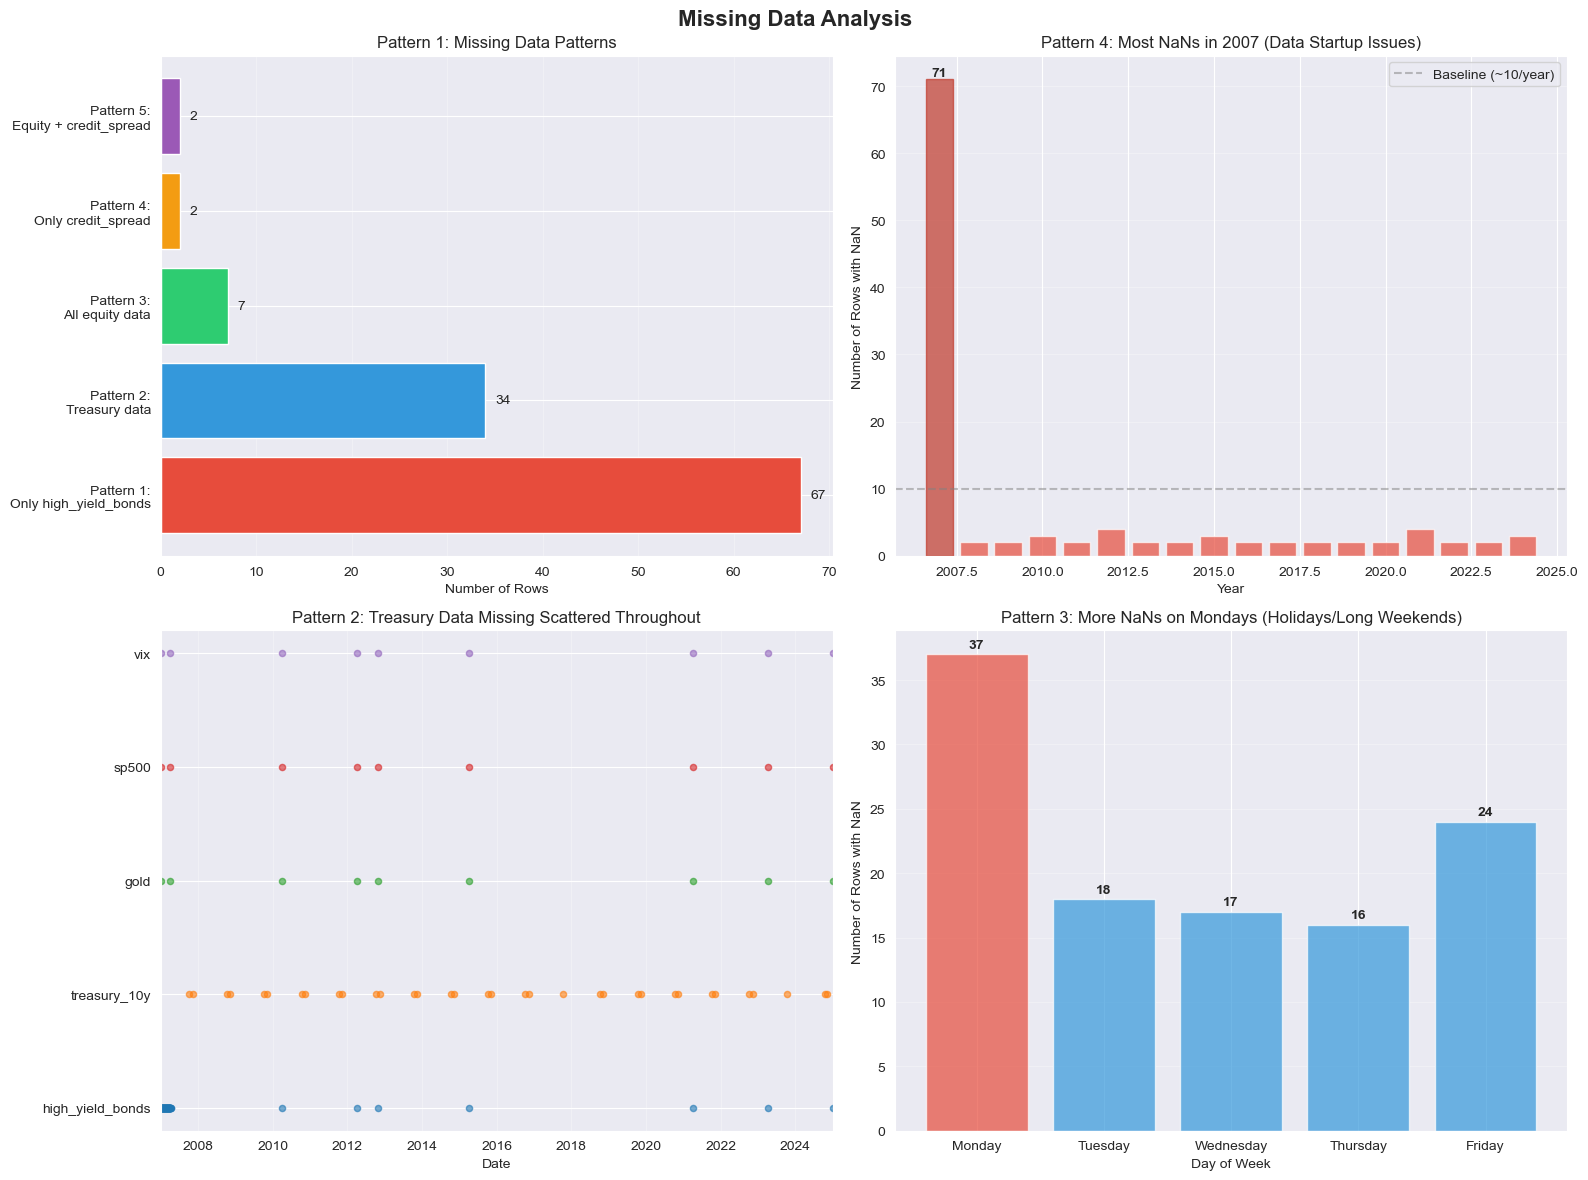

Visualization saved as 'missing_data_analysis.png'


In [89]:
# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Missing Data Analysis', fontsize=16, fontweight='bold')

# VISUAL 1: Missing data patterns (which columns missing together)
ax1 = axes[0, 0]
missing_patterns = nan_data.isna()
pattern_counts = missing_patterns.groupby(list(missing_patterns.columns)).size().sort_values(ascending=False)

# Simplify pattern labels for readability
pattern_labels = ['Pattern 1:\nOnly high_yield_bonds',
                  'Pattern 2:\nTreasury data',
                  'Pattern 3:\nAll equity data',
                  'Pattern 4:\nOnly credit_spread',
                  'Pattern 5:\nEquity + credit_spread']
counts = pattern_counts.head(5).values

ax1.barh(range(len(counts)), counts, color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6'])
ax1.set_yticks(range(len(counts)))
ax1.set_yticklabels(pattern_labels)
ax1.set_xlabel('Number of Rows')
ax1.set_title('Pattern 1: Missing Data Patterns')
ax1.grid(axis='x', alpha=0.3)

for i, v in enumerate(counts):
    ax1.text(v + 1, i, str(v), va='center')

# VISUAL 2: Missing data by year
ax2 = axes[0, 1]
nan_data['year'] = nan_data.index.year
yearly_nans = nan_data.groupby('year').size()

bars = ax2.bar(yearly_nans.index, yearly_nans.values, color='#e74c3c', alpha=0.7)
bars[0].set_color('#c0392b')  # Highlight 2007
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Rows with NaN')
ax2.set_title('Pattern 4: Most NaNs in 2007 (Data Startup Issues)')
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=10, color='gray', linestyle='--', alpha=0.5, label='Baseline (~10/year)')
ax2.legend()

for bar in bars:
    height = bar.get_height()
    if height > 20:
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# VISUAL 3: Timeline of missing data
ax3 = axes[1, 0]

# Create binary matrix for visualization
columns_to_show = ['high_yield_bonds', 'treasury_10y', 'gold', 'sp500', 'vix']
missing_matrix = nan_data[columns_to_show].isna().astype(int)

# Plot heatmap style
for i, col in enumerate(columns_to_show):
    missing_dates = nan_data[nan_data[col].isna()].index
    ax3.scatter(missing_dates, [i] * len(missing_dates), alpha=0.6, s=20)

ax3.set_yticks(range(len(columns_to_show)))
ax3.set_yticklabels(columns_to_show)
ax3.set_xlabel('Date')
ax3.set_title('Pattern 2: Treasury Data Missing Scattered Throughout')
ax3.grid(axis='x', alpha=0.3)
ax3.set_xlim(nan_data.index.min(), nan_data.index.max())

# VISUAL 4: Missing data by day of week
ax4 = axes[1, 1]
nan_data['day_of_week'] = nan_data.index.day_name()
day_counts = nan_data['day_of_week'].value_counts()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
day_counts_ordered = [day_counts.get(day, 0) for day in day_order]

colors_by_day = ['#e74c3c' if count > 30 else '#3498db' for count in day_counts_ordered]
ax4.bar(day_order, day_counts_ordered, color=colors_by_day, alpha=0.7)
ax4.set_xlabel('Day of Week')
ax4.set_ylabel('Number of Rows with NaN')
ax4.set_title('Pattern 3: More NaNs on Mondays (Holidays/Long Weekends)')
ax4.grid(axis='y', alpha=0.3)

for i, v in enumerate(day_counts_ordered):
    ax4.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('missing_data_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'missing_data_analysis.png'")

In [90]:
# storing the rows with NaN to CSV for history
nan_data.to_csv('nan_data.csv')

print(f"Saved {len(nan_data)} rows with NaN values to 'nan_data.csv'")
print("Download the file to inspect the missing data pattern")

Saved 112 rows with NaN values to 'nan_data.csv'
Download the file to inspect the missing data pattern


In [91]:
# CLEANING STRATEGY based on patterns identified

# Pattern 1 (67 rows): Only high_yield_bonds missing (Jan-April 2007)
# Solution: Drop rows before April 2007

# Pattern 2 (34 rows): Treasury data missing (scattered bond market holidays)
# Solution: Forward fill (carry last known treasury rates)

# Pattern 3 (7 rows): All equity missing (equity market closed, treasury open)
# Solution: Drop these rows (can't forward fill equity on treasury-only days)

# Pattern 4 & 5 (4 rows): Edge cases
# Solution: Forward fill

print("STEP 1: Drop rows where all equity data is missing")
equity_cols = ['gold', 'financials_sector', 'sp500', 'vix']
all_equity_missing = df[equity_cols].isna().all(axis=1)

print(f"Rows where all equity missing: {all_equity_missing.sum()}")
df_clean = df[~all_equity_missing].copy()

print("\nSTEP 2: Forward fill remaining NaNs")
print(f"\nBefore forward fill:")
print(df_clean.isna().sum())

df_clean = df_clean.fillna(method='ffill')

print(f"\nAfter forward fill:")
print(df_clean.isna().sum())

# If any NaNs remain at start (can't forward fill), backward fill
if df_clean.isna().any().any():
    print("\nSTEP 3: Backward fill for remaining start-of-dataset NaNs")
    df_clean = df_clean.fillna(method='bfill')

print(f"\nFINAL RESULT:")
print(f"  Remaining NaNs: {df_clean.isna().sum().sum()}")
print(f"  Final shape: {df_clean.shape}")
print(f"  Date range: {df_clean.index.min()} to {df_clean.index.max()}")

STEP 1: Drop rows where all equity data is missing
Rows where all equity missing: 9

STEP 2: Forward fill remaining NaNs

Before forward fill:
gold                  0
high_yield_bonds     67
financials_sector     0
sp500                 0
vix                   0
treasury_10y         34
treasury_2y          34
treasury_3m          34
credit_spread        36
dtype: int64

After forward fill:
gold                  0
high_yield_bonds     67
financials_sector     0
sp500                 0
vix                   0
treasury_10y          0
treasury_2y           0
treasury_3m           0
credit_spread         0
dtype: int64

STEP 3: Backward fill for remaining start-of-dataset NaNs

FINAL RESULT:
  Remaining NaNs: 0
  Final shape: (4529, 9)
  Date range: 2007-01-03 00:00:00 to 2024-12-30 00:00:00


In [92]:
print("=" * 60)
print("STEP 3.5: TARGETED TEMPORAL FEATURE ENGINEERING (SCALABLE)")
print("=" * 60)

# Work on a copy so the original dataframe stays intact
df_clean = df.copy(deep=True)
df_fe = df.copy(deep=True)

print("\nCreating lagged and rolling features for key indicators...")

# Create yield curve if it does not already exist
# Yield curve = short-term rate minus long-term rate
if 'yield_curve' not in df_fe.columns:
    df_fe['yield_curve'] = df_fe['treasury_2y'] - df_fe['treasury_10y']

# Configuration for temporal feature generation
# Adjust values here to change feature behavior

# Lagged features capture delayed effects
LAG_FEATURES = {
    'vix': [21, 63],
    'yield_curve': [21],
}

# Rolling statistics capture regime shifts and volatility buildup
ROLLING_FEATURES = {
    'vix': {
        'mean': [21],
        'std': [21]
    },
    'yield_curve': {
        'mean': [63]
    }
}

# Returns capture momentum and rate of deterioration
RETURN_FEATURES = {
    'sp500': [21, 63],
    'gold': [21, 63]
}

# Generate lagged features using past values only
for feature, lags in LAG_FEATURES.items():
    for lag in lags:
        df_fe[f"{feature}_lag_{lag}d"] = df_fe[feature].shift(lag)

# Generate rolling statistical features
for feature, stats in ROLLING_FEATURES.items():
    for stat, windows in stats.items():
        for window in windows:
            if stat == 'mean':
                df_fe[f"{feature}_rolling_mean_{window}d"] = (
                    df_fe[feature].rolling(window=window).mean()
                )
            elif stat == 'std':
                df_fe[f"{feature}_rolling_std_{window}d"] = (
                    df_fe[feature].rolling(window=window).std()
                )

# Generate return / momentum features
for feature, windows in RETURN_FEATURES.items():
    for window in windows:
        df_fe[f"{feature}_return_{window}d"] = df_fe[feature].pct_change(window)

# Drop rows with missing values caused by lagging and rolling windows
initial_rows = df_fe.shape[0]
df_fe = df_fe.dropna()
final_rows = df_fe.shape[0]

print(f"\nDropped {initial_rows - final_rows} rows due to rolling/lag features.")
print(f"Final dataset shape: {df_fe.shape}")

# Feature engineering is complete and frozen

STEP 3.5: TARGETED TEMPORAL FEATURE ENGINEERING (SCALABLE)

Creating lagged and rolling features for key indicators...

Dropped 1670 rows due to rolling/lag features.
Final dataset shape: (2868, 20)


In [93]:
print("=" * 60)
print("STEP 4: CREATE TARGET VARIABLE - RECESSION INDICATOR")
print("=" * 60)

STEP 4: CREATE TARGET VARIABLE - RECESSION INDICATOR


In [94]:
# datetime index validation
print("\n Step 1: Ensuring proper datetime index...")
df_fe.index = pd.to_datetime(df_fe.index)

# Checks if your index has timezone info (like UTC, EST, etc.)
# If yes, removes it (makes it "timezone-naive")
# If no, confirms it's already clean

if df_fe.index.tz is not None:
    df_fe.index = df_fe.index.tz_localize(None)
    print("    Timezone removed for consistency")
else:
    print("    Index already timezone-naive")

# data type of index
print(f"   Index type: {type(df_fe.index)}")
print(f"   Date range: {df_fe.index.min()} to {df_fe.index.max()}")


 Step 1: Ensuring proper datetime index...
    Index already timezone-naive
   Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
   Date range: 2007-05-08 00:00:00 to 2024-10-11 00:00:00


In [95]:
print("\n Step 2: Defining NBER recession periods...")

# defining all potential NBER recessions
ALL_RECESSIONS = [
    ('2001-03-01', '2001-11-30'),  # Dot-com crash
    ('2007-12-01', '2009-06-30'),  # Great Financial Crisis  
    ('2020-02-01', '2020-04-30'),  # COVID-19
]

# to only use recessions that are FULLY within our data range
data_start = df_fe.index.min()
data_end = df_fe.index.max()

NBER_RECESSIONS = []

for start, end in ALL_RECESSIONS:
    start_date = pd.to_datetime(start)
    end_date = pd.to_datetime(end)
    
    # Check if ENTIRE recession period is within our data
    if start_date >= data_start and end_date <= data_end:
        NBER_RECESSIONS.append((start, end))
        print(f"   ✅ Including: {start} to {end}")
    else:
        print(f"   ⏭️  Skipping: {start} to {end} (outside data range)")

print(f"\n Using {len(NBER_RECESSIONS)} recession periods")


 Step 2: Defining NBER recession periods...
   ⏭️  Skipping: 2001-03-01 to 2001-11-30 (outside data range)
   ✅ Including: 2007-12-01 to 2009-06-30
   ✅ Including: 2020-02-01 to 2020-04-30

 Using 2 recession periods


In [96]:
# creating the target variable
print("\n Step 3: Creating binary recession indicator...")
df_fe['recession'] = 0

# Creates a boolean mask (True/False for each row)
# True = date is within recession period
# False = date is outside recession period

for start_date, end_date in NBER_RECESSIONS:
    mask = (df_fe.index >= start_date) & (df_fe.index <= end_date)
    df_fe.loc[mask, 'recession'] = 1
    days_marked = mask.sum()
    print(f"   Marked {days_marked} days as recession: {start_date} to {end_date}")


 Step 3: Creating binary recession indicator...
   Marked 264 days as recession: 2007-12-01 to 2009-06-30
   Marked 55 days as recession: 2020-02-01 to 2020-04-30


In [97]:
# understanding recession vs normal days
print("\n" + "=" * 60)
print("TARGET VARIABLE ANALYSIS")
print("=" * 60)

# shows you the split between classes
print(f"\n Class Distribution:")
print(f"   Total trading days: {total_days}")
print(f"   Recession days (1): {recession_days} ({recession_pct:.1f}%)")
print(f"   Non-recession days (0): {total_days - recession_days} ({100-recession_pct:.1f}%)")

imbalance_ratio = (total_days - recession_days) / recession_days
print(f"\n  Class Imbalance Ratio: {imbalance_ratio:.1f}:1")


TARGET VARIABLE ANALYSIS

 Class Distribution:
   Total trading days: 6575
   Recession days (1): 319 (11.1%)
   Non-recession days (0): 6256 (88.9%)

  Class Imbalance Ratio: 19.6:1


In [98]:
if recession_pct < 15:
    print("\n🚨 IMPORTANT: Highly imbalanced dataset!")
    print("   When modeling, you MUST:")
    print("   • Use class_weight='balanced' (Logistic Regression, Random Forest)")
    print("   • Use scale_pos_weight parameter (XGBoost)")
    print("   • Evaluate with ROC-AUC and PR-AUC (not accuracy)")
    print("   • Consider SMOTE or other resampling techniques")


🚨 IMPORTANT: Highly imbalanced dataset!
   When modeling, you MUST:
   • Use class_weight='balanced' (Logistic Regression, Random Forest)
   • Use scale_pos_weight parameter (XGBoost)
   • Evaluate with ROC-AUC and PR-AUC (not accuracy)
   • Consider SMOTE or other resampling techniques


^ What it does ^:

IF recessions are less than 15% of data → prints warning
Reminds you how to handle imbalance in modeling

Why this matters - THE KEY INSIGHT:

If 85% of data is "not recession", a dumb model can predict "0" always and get 85% accuracy!
Need special techniques to force the model to learn from the minority class

In [101]:
print("\n Recession Days by Year:")
yearly_recession = df_fe.groupby(df_fe.index.year)['recession'].agg(['sum', 'count'])
yearly_recession['pct'] = (yearly_recession['sum'] / yearly_recession['count'] * 100).round(1)
yearly_recession.columns = ['Recession Days', 'Total Days', 'Recession %']
print(yearly_recession[yearly_recession['Recession Days'] > 0])

print("\n Target variable 'recession' created successfully!")
print(f"   Final dataset shape: {df_fe.shape}")
print(f"   Features: {df_fe.shape[1] - 1} (+ 1 target)")


 Recession Days by Year:
      Recession Days  Total Days  Recession %
2008             168         168        100.0
2009              96         167         57.5
2020              55         168         32.7

 Target variable 'recession' created successfully!
   Final dataset shape: (2868, 21)
   Features: 20 (+ 1 target)


In [103]:
df_fe.sample(8)

,gold,high_yield_bonds,financials_sector,sp500,vix,treasury_10y,treasury_2y,treasury_3m,credit_spread,yield_curve,...,vix_lag_63d,yield_curve_lag_21d,vix_rolling_mean_21d,vix_rolling_std_21d,yield_curve_rolling_mean_63d,sp500_return_21d,sp500_return_63d,gold_return_21d,gold_return_63d,recession
2022-04-14,184.039993,64.285133,34.566750,4392.589844,22.700001,2.83,2.47,0.79,1.93,-0.36,...,20.309999,-0.24,21.793810,1.977429,-0.385079,0.007970,-0.057188,0.022388,0.081570,0
2013-08-28,136.710007,46.727882,12.561286,1634.959961,16.490000,2.78,0.40,0.03,2.65,-2.38,...,14.530000,-2.30,13.916667,1.445034,-2.192540,-0.030250,-0.011757,0.067047,0.000073,0
2015-05-08,113.970001,51.488667,16.439428,2116.100098,12.860000,2.16,0.59,0.01,2.65,-1.57,...,18.549999,-1.41,13.334286,0.868208,-1.412857,0.011917,0.033888,-0.006104,-0.043635,0
2018-04-04,126.449997,56.352604,23.835411,2644.689941,20.059999,2.79,2.28,1.71,1.85,-0.51,...,9.770000,-0.64,19.213810,2.975059,-0.594286,-0.028023,-0.018963,0.010145,0.010387,0
2007-06-07,65.260002,32.630825,20.675663,1490.719971,17.059999,5.11,5.03,4.80,1.60,-0.08,...,14.090000,0.05,13.582381,0.949189,-0.004603,-0.011275,0.062644,-0.038597,0.015720,0
2020-09-14,183.889999,63.129875,22.728300,3383.540039,25.850000,0.68,0.14,0.11,2.66,-0.54,...,34.400002,-0.55,25.426667,3.648548,-0.503333,0.002997,0.103356,0.003055,0.132816,0
2017-06-09,120.540001,55.915836,20.623909,2431.770020,10.700000,2.21,1.35,1.01,2.21,-0.86,...,11.660000,-1.06,10.858571,1.507419,-1.040000,0.013394,0.024939,0.038780,0.050732,0
2018-01-09,124.730003,57.126835,24.583010,2751.290039,10.080000,2.55,1.98,1.44,1.74,-0.57,...,10.330000,-0.57,9.839524,0.488236,-0.648730,0.043349,0.081172,0.052663,0.021707,0
